# 03 — Análise Bivariada

Cruzamos o desempenho dos candidatos com variáveis socioeconômicas e demográficas para revelar padrões de desigualdade educacional.

**Seções:**
1. Desempenho × Tipo de escola
2. Desempenho × Faixa de renda
3. Desempenho × Cor/raça
4. Desempenho × Sexo
5. Análise combinada: renda + escola

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.insert(0, '../src')
from utils import (
    NOTAS_COLS, NOTAS_LABELS, MAPA_RENDA,
    configurar_estilo, salvar_figura
)

configurar_estilo()

df = pd.read_parquet('../data/processed/amostra_limpa.parquet')
print(f'Shape: {df.shape}')

# Rótulos abreviados para eixos com faixas de renda
RENDA_CURTA = [
    'Nenhuma', '≤1,3k', '1,3-2k', '2-2,6k', '2,6-3,3k',
    '3,3-4k', '4-5,3k', '5,3-6,6k', '6,6-7,9k', '7,9-9,2k',
    '9,2-11k', '11-13k', '13-20k', '20-26k', '26-40k', '>40k'
]
ORDEM_RENDA = list(MAPA_RENDA.values())
MAPA_RENDA_CURTA = dict(zip(ORDEM_RENDA, RENDA_CURTA))

Shape: (370141, 11)


## 1. Desempenho × Tipo de Escola

Comparamos candidatos de escolas **públicas** e **privadas** em cada área do exame. Excluímos os que não informaram o tipo de escola (`TP_ESCOLA = 'Não respondeu'`) para evitar ruído na comparação.

In [2]:
df_escola = df[df['TP_ESCOLA'].isin(['Pública', 'Privada'])].copy()
df_escola['TP_ESCOLA'] = df_escola['TP_ESCOLA'].cat.remove_unused_categories()
print(f'Registros usados: {len(df_escola):,}')
print(df_escola['TP_ESCOLA'].value_counts())

Registros usados: 169,087
TP_ESCOLA
Pública    147648
Privada     21439
Name: count, dtype: int64


Figura salva: ../reports/figures/03_notas_por_escola.png


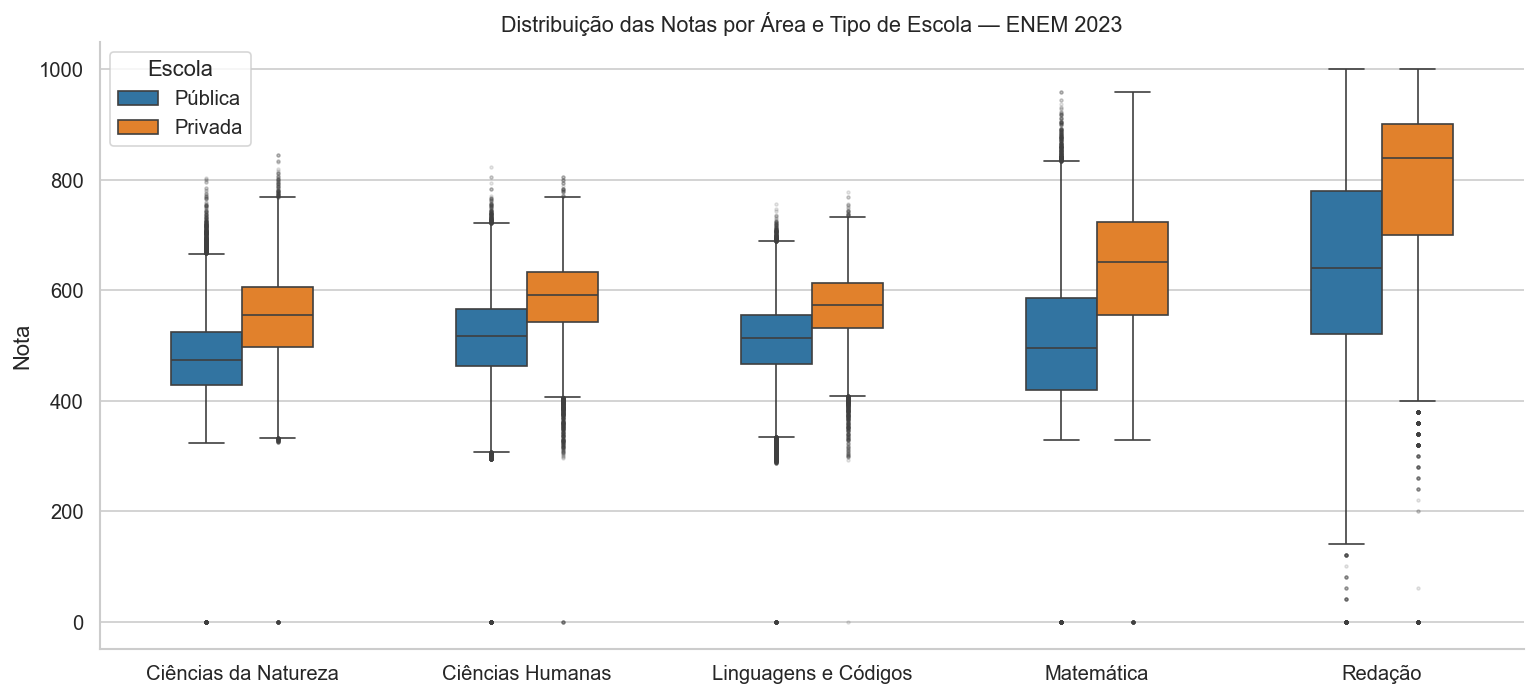

In [3]:
df_melt_escola = df_escola[NOTAS_COLS + ['TP_ESCOLA']].melt(
    id_vars='TP_ESCOLA', var_name='Area', value_name='Nota'
)
df_melt_escola['Area'] = df_melt_escola['Area'].map(NOTAS_LABELS)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=df_melt_escola, x='Area', y='Nota', hue='TP_ESCOLA',
    hue_order=['Pública', 'Privada'],
    palette={'Pública': '#1f77b4', 'Privada': '#ff7f0e'},
    width=0.5, flierprops=dict(marker='o', markersize=1.5, alpha=0.2), ax=ax
)
ax.set_title('Distribuição das Notas por Área e Tipo de Escola — ENEM 2023', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Nota')
ax.legend(title='Escola')
plt.tight_layout()
salvar_figura(fig, '03_notas_por_escola')
plt.show()

In [4]:
# Tabela: média por área e diferença pública vs privada
col_labels = {**NOTAS_LABELS, 'NOTA_MEDIA': 'Nota Média'}

medias = (
    df_escola.groupby('TP_ESCOLA', observed=True)[NOTAS_COLS + ['NOTA_MEDIA']]
    .mean()
    .round(1)
)
medias.columns = [col_labels[c] for c in medias.columns]

diferenca = (medias.loc['Privada'] - medias.loc['Pública']).rename('Diferença (pts)')
tabela = medias.T
tabela['Diferença (pts)'] = diferenca
tabela['Diferença (%)'] = ((diferenca / medias.loc['Pública']) * 100).round(1)
tabela

TP_ESCOLA,Privada,Pública,Diferença (pts),Diferença (%)
Ciências da Natureza,551.8,474.8,77.0,16.2
Ciências Humanas,583.8,510.8,73.0,14.3
Linguagens e Códigos,568.1,508.2,59.9,11.8
Matemática,636.2,505.9,130.3,25.8
Redação,793.7,631.0,162.7,25.8
Nota Média,626.7,526.1,100.6,19.1


## 2. Desempenho × Faixa de Renda

A renda familiar é uma das variáveis com maior poder explicativo no ENEM. As 16 faixas do questionário (A a P) cobrem desde sem renda até acima de R$ 39.600 mensais.

Figura salva: ../reports/figures/03_nota_por_renda.png


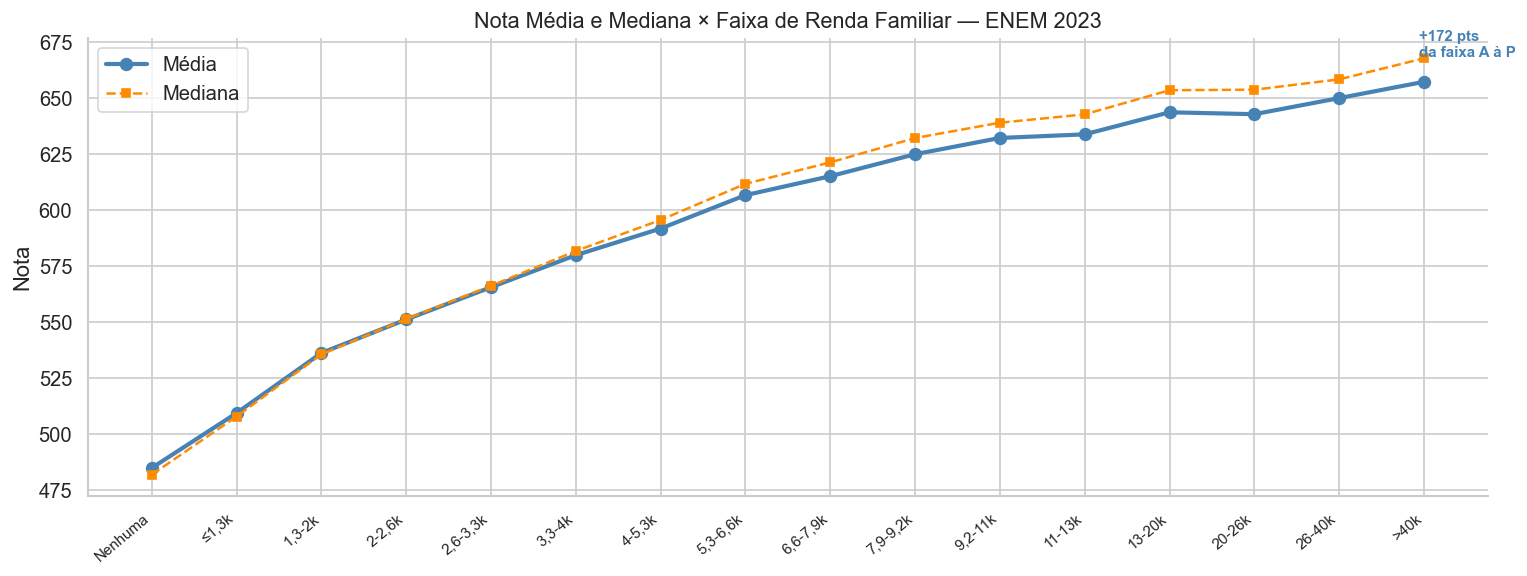

In [5]:
# Nota média por faixa de renda (na ordem A → P)
renda_valida = [r for r in ORDEM_RENDA if r in df['Q006'].cat.categories]

nota_renda = (
    df.groupby('Q006', observed=True)['NOTA_MEDIA']
    .agg(['mean', 'median', 'count'])
    .reindex(renda_valida)
    .reset_index()
)
nota_renda['renda_curta'] = nota_renda['Q006'].map(MAPA_RENDA_CURTA)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(nota_renda.index, nota_renda['mean'],
        marker='o', linewidth=2.5, color='steelblue', markersize=7, label='Média')
ax.plot(nota_renda.index, nota_renda['median'],
        marker='s', linewidth=1.5, color='darkorange', linestyle='--',
        markersize=5, label='Mediana')

ax.set_xticks(nota_renda.index)
ax.set_xticklabels(nota_renda['renda_curta'], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Nota')
ax.set_title('Nota Média e Mediana × Faixa de Renda Familiar — ENEM 2023', fontsize=13)
ax.legend()

# Anota variação total
variacao = nota_renda['mean'].iloc[-1] - nota_renda['mean'].iloc[0]
ax.annotate(
    f'+{variacao:.0f} pts\nda faixa A à P',
    xy=(nota_renda.index[-1], nota_renda['mean'].iloc[-1]),
    xytext=(-3, 15), textcoords='offset points',
    fontsize=9, color='steelblue', fontweight='bold'
)

plt.tight_layout()
salvar_figura(fig, '03_nota_por_renda')
plt.show()

Figura salva: ../reports/figures/03_heatmap_renda_area.png


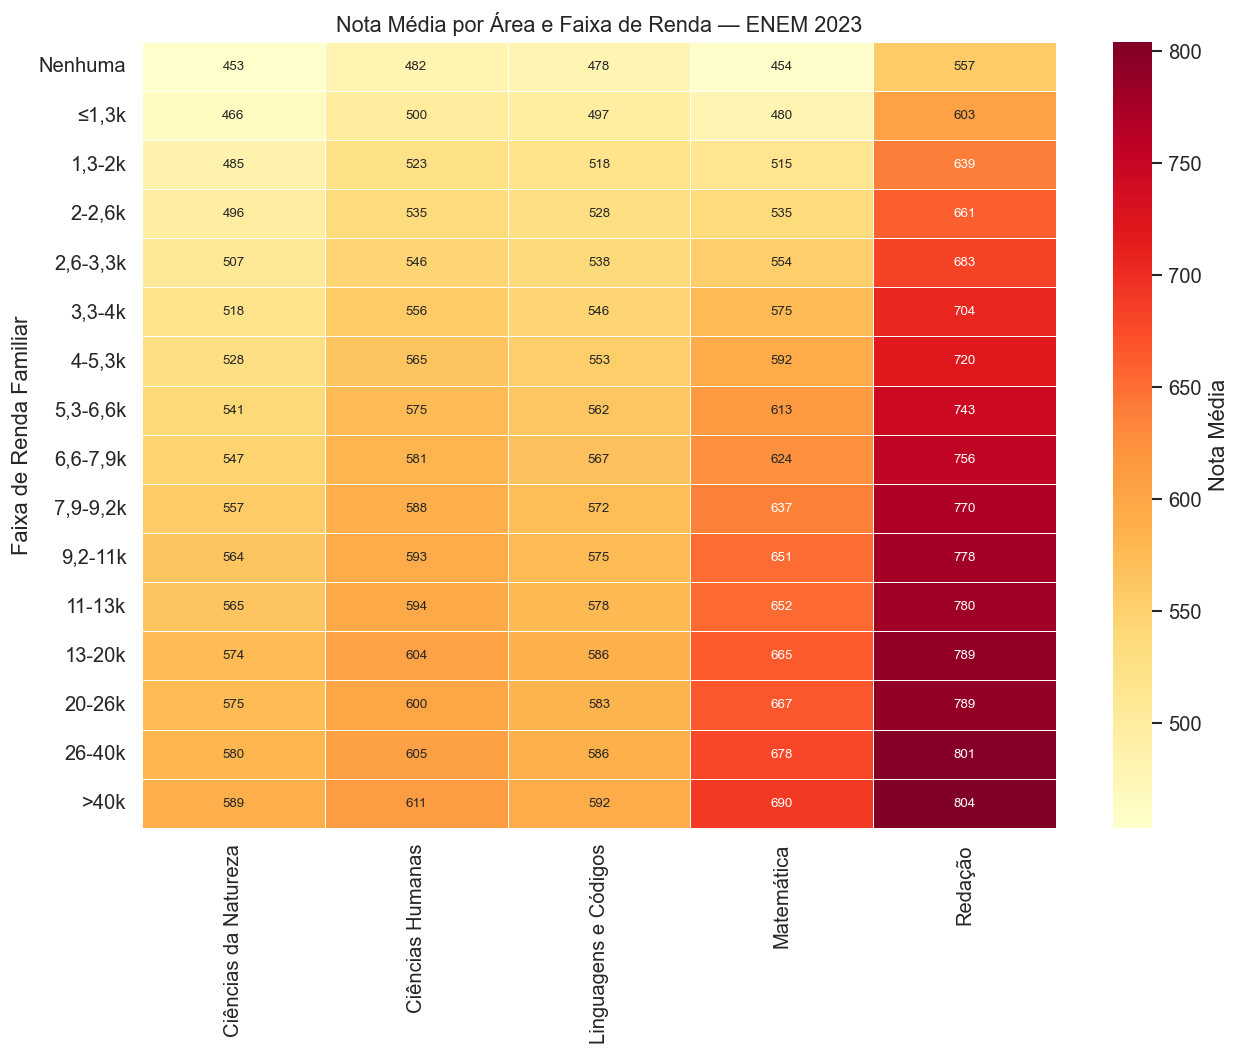

In [6]:
# Heatmap: nota média por área × faixa de renda
pivot_renda = (
    df.groupby('Q006', observed=True)[NOTAS_COLS]
    .mean()
    .reindex(renda_valida)
    .round(1)
)
pivot_renda.index = [MAPA_RENDA_CURTA[r] for r in pivot_renda.index]
pivot_renda.columns = [NOTAS_LABELS[c] for c in pivot_renda.columns]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    pivot_renda, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.3, ax=ax, cbar_kws={'label': 'Nota Média'},
    annot_kws={'size': 8}
)
ax.set_title('Nota Média por Área e Faixa de Renda — ENEM 2023', fontsize=13)
ax.set_ylabel('Faixa de Renda Familiar')
ax.set_xlabel('')
plt.tight_layout()
salvar_figura(fig, '03_heatmap_renda_area')
plt.show()

## 3. Desempenho × Cor/Raça

Analisamos apenas os grupos com representação expressiva na amostra (mínimo de 1.000 candidatos).

C:\Users\rodri\AppData\Local\Temp\ipykernel_10388\2392015502.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Figura salva: ../reports/figures/03_nota_por_raca.png


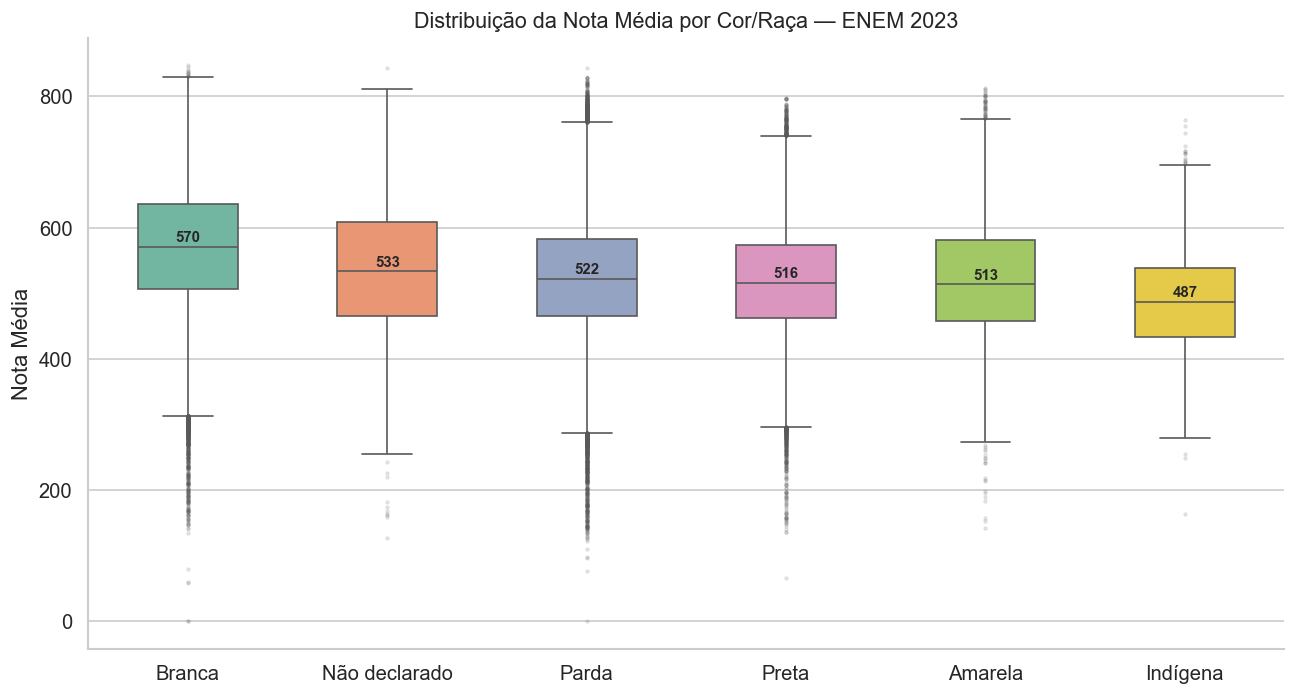

In [7]:
racas_validas = (
    df['TP_COR_RACA'].value_counts()
    .loc[lambda s: s >= 1000]
    .index.tolist()
)
df_raca = df[df['TP_COR_RACA'].isin(racas_validas)].copy()

order_raca = (
    df_raca.groupby('TP_COR_RACA', observed=True)['NOTA_MEDIA']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=df_raca, x='TP_COR_RACA', y='NOTA_MEDIA',
    order=order_raca, palette='Set2', width=0.5,
    flierprops=dict(marker='o', markersize=1.5, alpha=0.2), ax=ax
)

# Anota mediana em cada caixa
medianas = df_raca.groupby('TP_COR_RACA', observed=True)['NOTA_MEDIA'].median()
for i, raca in enumerate(order_raca):
    ax.text(i, medianas[raca] + 8, f'{medianas[raca]:.0f}',
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('Distribuição da Nota Média por Cor/Raça — ENEM 2023', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Nota Média')
plt.tight_layout()
salvar_figura(fig, '03_nota_por_raca')
plt.show()

## 4. Desempenho × Sexo

O ENEM apresenta padrões distintos por área: historicamente, candidatos do sexo masculino tendem a pontuar mais em Matemática, enquanto candidatas femininas se destacam em Redação.

Figura salva: ../reports/figures/03_notas_por_sexo.png


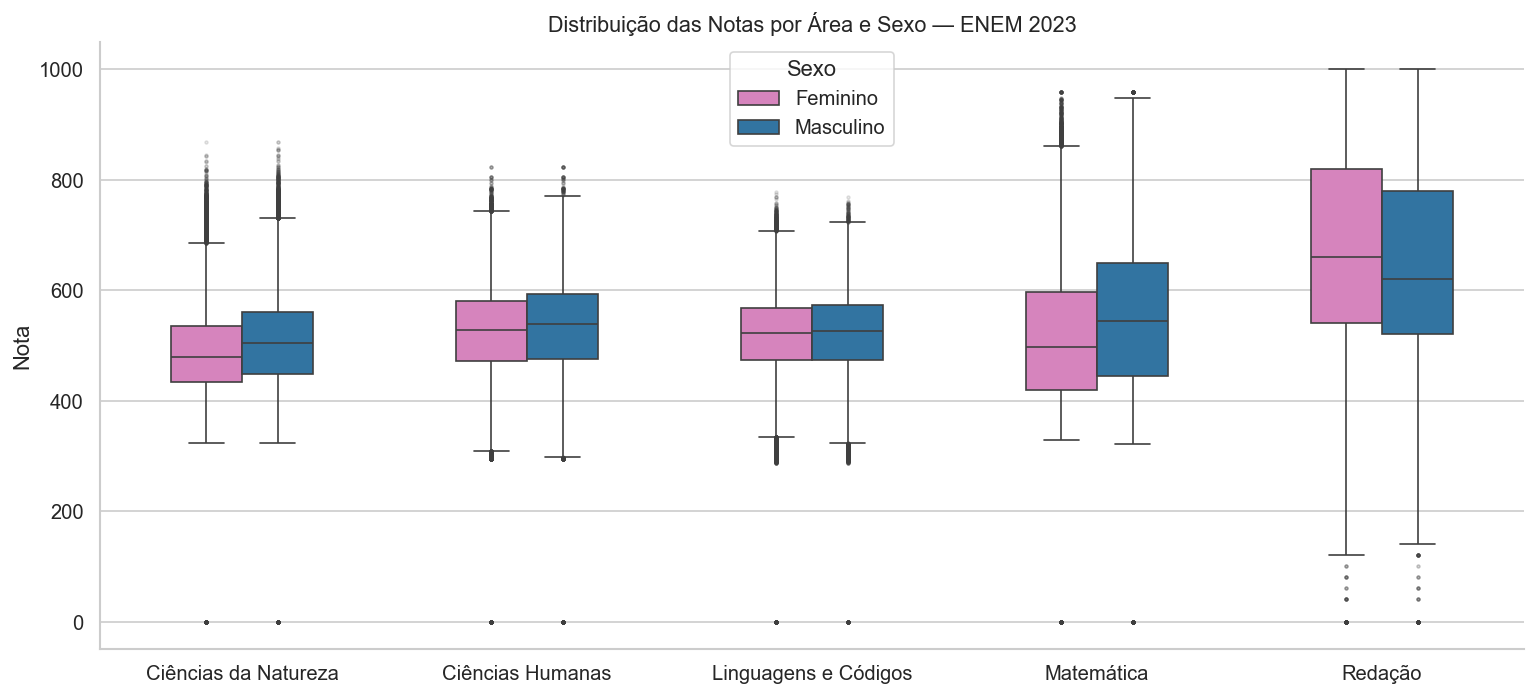

In [8]:
df_melt_sexo = df[NOTAS_COLS + ['TP_SEXO']].melt(
    id_vars='TP_SEXO', var_name='Area', value_name='Nota'
)
df_melt_sexo['Area'] = df_melt_sexo['Area'].map(NOTAS_LABELS)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=df_melt_sexo, x='Area', y='Nota', hue='TP_SEXO',
    palette={'Feminino': '#e377c2', 'Masculino': '#1f77b4'},
    width=0.5, flierprops=dict(marker='o', markersize=1.5, alpha=0.2), ax=ax
)
ax.set_title('Distribuição das Notas por Área e Sexo — ENEM 2023', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Nota')
ax.legend(title='Sexo')
plt.tight_layout()
salvar_figura(fig, '03_notas_por_sexo')
plt.show()

In [9]:
# Diferença de média por área e sexo
medias_sexo = (
    df.groupby('TP_SEXO', observed=True)[NOTAS_COLS]
    .mean()
    .round(1)
)
medias_sexo.columns = [NOTAS_LABELS[c] for c in medias_sexo.columns]
diff_sexo = (medias_sexo.loc['Masculino'] - medias_sexo.loc['Feminino']).rename('Diferença M − F (pts)')
print(diff_sexo.to_string())
print('\n+ = homens maior  |  - = mulheres maior')

Ciências da Natureza    19.6
Ciências Humanas         7.8
Linguagens e Códigos     1.0
Matemática              38.1
Redação                -39.3

+ = homens maior  |  - = mulheres maior


## 5. Análise Combinada: Renda × Escola

Renda e tipo de escola são variáveis correlacionadas — estudantes de famílias mais ricas tendem a estudar em escolas privadas. Aqui investigamos se a vantagem da escola privada se mantém **dentro da mesma faixa de renda**, o que indicaria um efeito independente do tipo de escola.

Figura salva: ../reports/figures/03_escola_por_renda.png


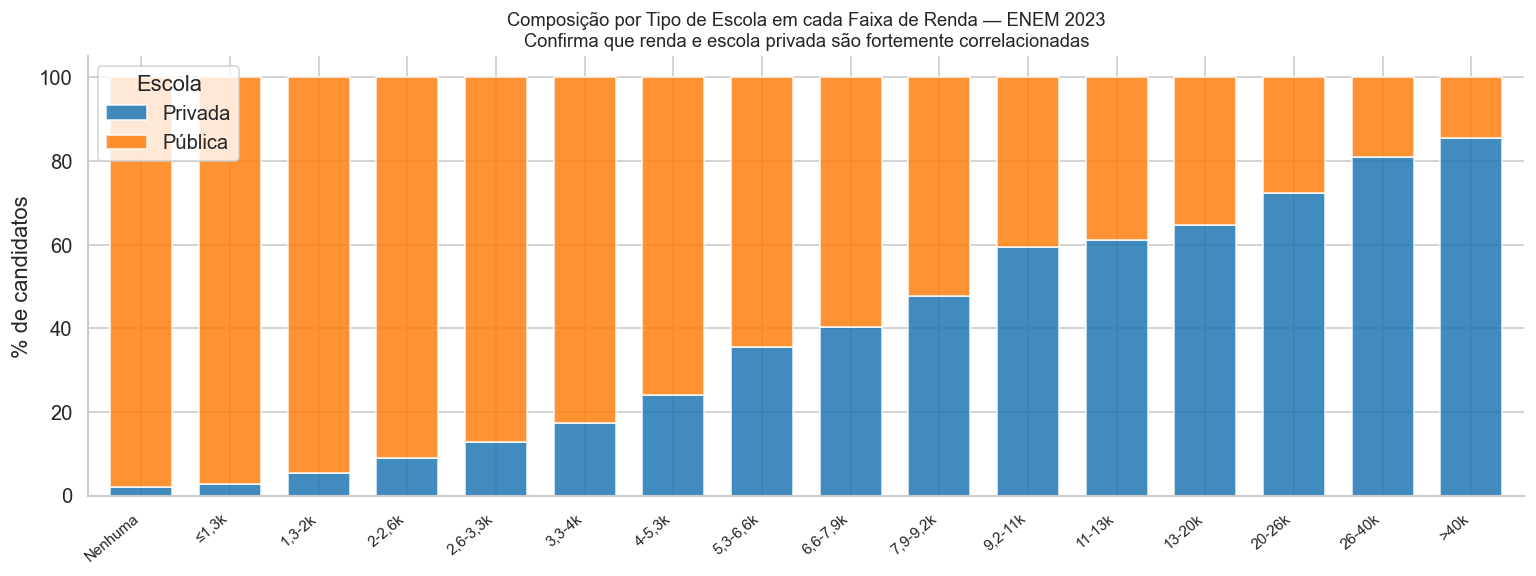

In [10]:
# Composição de escola por faixa de renda
df_comb = df[df['TP_ESCOLA'].isin(['Pública', 'Privada'])].copy()
df_comb['TP_ESCOLA'] = df_comb['TP_ESCOLA'].cat.remove_unused_categories()

prop = (
    df_comb.groupby(['Q006', 'TP_ESCOLA'], observed=True)
    .size()
    .unstack(fill_value=0)
)
prop = prop.div(prop.sum(axis=1), axis=0).mul(100).reindex(
    [r for r in ORDEM_RENDA if r in prop.index]
)
prop.index = [MAPA_RENDA_CURTA.get(r, r) for r in prop.index]

fig, ax = plt.subplots(figsize=(13, 5))
prop.plot(kind='bar', stacked=True, ax=ax,
          color=['#1f77b4', '#ff7f0e'], alpha=0.85, width=0.7)
ax.set_xticklabels(prop.index, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('% de candidatos')
ax.set_title(
    'Composição por Tipo de Escola em cada Faixa de Renda — ENEM 2023\n'
    'Confirma que renda e escola privada são fortemente correlacionadas',
    fontsize=11
)
ax.legend(title='Escola')
plt.tight_layout()
salvar_figura(fig, '03_escola_por_renda')
plt.show()

Figura salva: ../reports/figures/03_nota_renda_por_escola.png


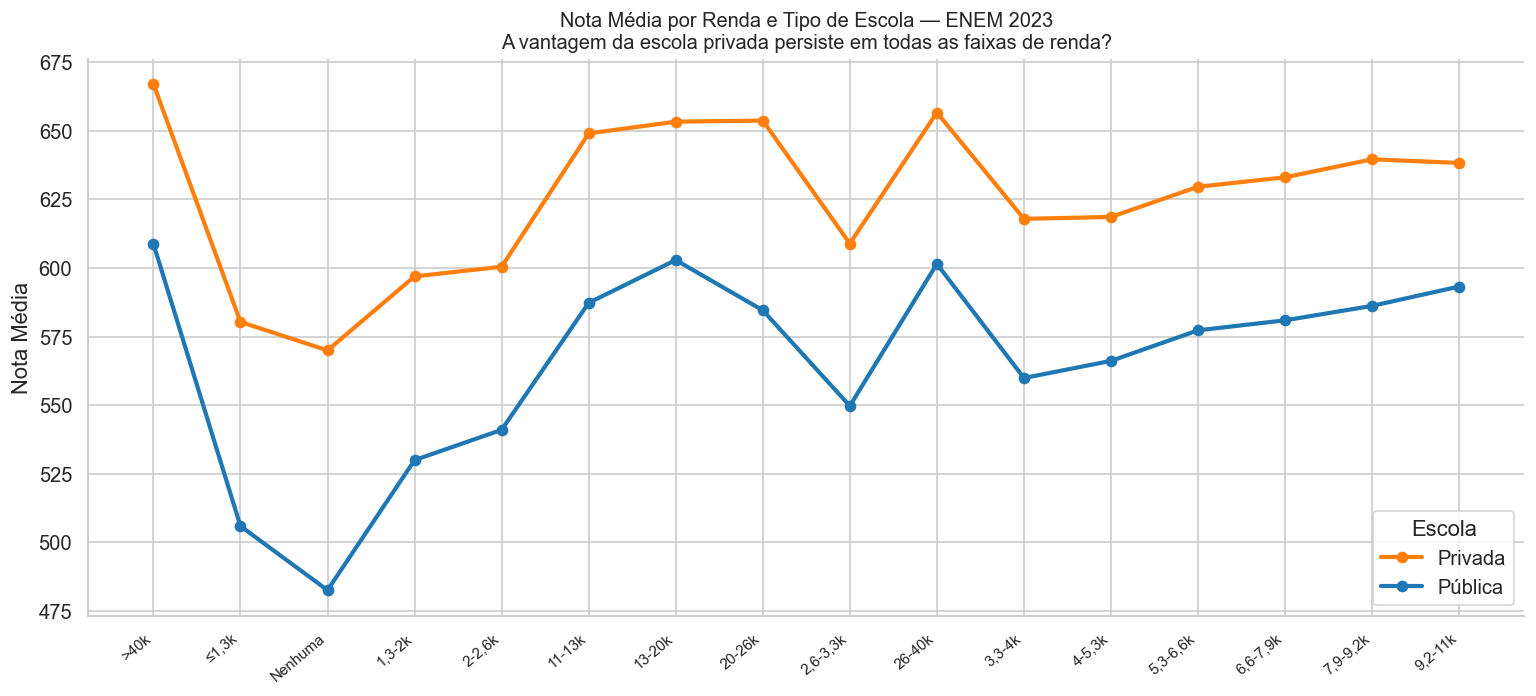

In [11]:
# Nota média por renda, separada por tipo de escola
nota_comb = (
    df_comb.groupby(['Q006', 'TP_ESCOLA'], observed=True)['NOTA_MEDIA']
    .mean()
    .reset_index()
)
nota_comb = nota_comb[nota_comb['Q006'].isin(renda_valida)].copy()
nota_comb['ordem'] = nota_comb['Q006'].apply(
    lambda x: ORDEM_RENDA.index(x) if x in ORDEM_RENDA else 99
)
nota_comb = nota_comb.sort_values('ordem')
nota_comb['renda_curta'] = nota_comb['Q006'].map(MAPA_RENDA_CURTA)

fig, ax = plt.subplots(figsize=(13, 6))
cores = {'Pública': '#1f77b4', 'Privada': '#ff7f0e'}
for escola, grp in nota_comb.groupby('TP_ESCOLA', observed=True):
    ax.plot(
        range(len(grp)), grp['NOTA_MEDIA'].values,
        marker='o', label=escola, color=cores[escola], linewidth=2.5
    )

ticks_labels = nota_comb[nota_comb['TP_ESCOLA'] == 'Pública']['renda_curta'].values
ax.set_xticks(range(len(ticks_labels)))
ax.set_xticklabels(ticks_labels, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Nota Média')
ax.set_title(
    'Nota Média por Renda e Tipo de Escola — ENEM 2023\n'
    'A vantagem da escola privada persiste em todas as faixas de renda?',
    fontsize=12
)
ax.legend(title='Escola')
plt.tight_layout()
salvar_figura(fig, '03_nota_renda_por_escola')
plt.show()

## 6. Principais Insights

| # | Insight | Evidência |
|---|---|---|
| 1 | **Escola privada supera pública em todas as áreas** | Maior gap em Redação (+163 pts) e Matemática (+130 pts); média geral +101 pts |
| 2 | **Renda e desempenho têm relação monotônica** | Variação de +172 pts entre a faixa A (sem renda, média 485) e a faixa P (>R$ 39.6k, média 657) |
| 3 | **Candidatos indígenas, pretos e pardos pontuam abaixo da média** | Indígenas: −82 pts vs brancos; pretos: −52 pts; pardos: −46 pts |
| 4 | **Homens pontuam mais em MT; mulheres em Redação** | Diferença de +38 pts em Matemática (homens) e +39 pts em Redação (mulheres) |
| 5 | **A vantagem da escola privada independe da renda** | Privada supera pública em **todas** as 16 faixas de renda — gap mínimo de 45 pts, máximo de 87 pts |

> **Insight 5 é o mais relevante:** mesmo candidatos sem renda que estudaram em escola privada pontuam, em média, 87 pontos a mais do que os de escola pública na mesma faixa. Isso sugere que o tipo de escola tem efeito independente da renda familiar.

**Próximo passo:** `03b_analise_geografica.ipynb` — mapa interativo com desempenho por estado.